In [ ]:
#Evaluacion N°2 Mineria de Datos
#Gastos Militares


#Integrantes: Andrés Álvarez ,Raul Barrera
#Fecha: 28-05-2026

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, KBinsDiscretizer, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score

In [ ]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

# Para ver todas las filas (cuidado si el dataset es muy grande)
pd.set_option('display.max_rows', None)

In [ ]:
# Carga de datos
data_frame = pd.read_csv("/content/military-spending-sipri.csv", low_memory=False)
data_frame.head()


,Entity,Code,Year,Military expenditure,World region according to OWID
0,Afghanistan,AFG,1970,68814760.0,Asia
1,Afghanistan,AFG,1973,79796820.0,Asia
2,Afghanistan,AFG,1974,77561210.0,Asia
3,Afghanistan,AFG,1975,81419624.0,Asia
4,Afghanistan,AFG,1976,103842290.0,Asia


### Carga inicial del dataset

Primero, cargamos el dataset original `military-spending-sipri.csv`. Este archivo contiene información detallada sobre el gasto militar por país, año y región. Es el punto de partida para todo nuestro análisis.

In [ ]:
data_frame_new = data_frame[['Entity', 'Year','Military expenditure']]
data_frame_new.head()
data_frame_new.to_csv('military-spending-sipri_new.csv')
#Guardaremos un csv nuevo, limpio

In [ ]:
# Carga de datos
data_frame_new = pd.read_csv("/content/military-spending-sipri_new.csv", low_memory=False)
data_frame_new.head()

,Unnamed: 0,Entity,Year,Military expenditure
0,0,Afghanistan,1970,68814760.0
1,1,Afghanistan,1973,79796820.0
2,2,Afghanistan,1974,77561210.0
3,3,Afghanistan,1975,81419624.0
4,4,Afghanistan,1976,103842290.0


In [ ]:
import pandas as pd

# Usar el DataFrame original y copiarlo para no modificar el original
df_continent_expenditure = data_frame.copy()

# Renombrar la columna de región a Continente para mayor claridad
df_continent_expenditure.rename(columns={'World region according to OWID': 'Continent'}, inplace=True)

# Eliminar filas con valores nulos en Continente o Gasto Militar, ya que son esenciales para el análisis
df_continent_expenditure.dropna(subset=['Continent', 'Military expenditure'], inplace=True)

# Definir la función para asignar las décadas según lo solicitado
def assign_decade(year):
    if 1949 <= year <= 1959:
        return '1949-1959'
    elif 1960 <= year <= 1970:
        return '1960-1970'
    elif 1971 <= year <= 1981:
        return '1971-1981'
    elif 1982 <= year <= 1992:
        return '1982-1992'
    elif 1993 <= year <= 2003:
        return '1993-2003'
    elif 2004 <= year <= 2014:
        return '2004-2014'
    elif 2015 <= year <= 2024:
        return '2015-2024'
    else:
        return None # Excluir años fuera de las décadas especificadas

# Aplicar la función para crear la nueva columna 'Decade'
df_continent_expenditure['Decade'] = df_continent_expenditure['Year'].apply(assign_decade)

# Eliminar filas donde la década no pudo ser asignada (None)
df_continent_expenditure.dropna(subset=['Decade'], inplace=True)

# Agrupar por Continente y Década y sumar el 'Gasto militar'
df_grouped = df_continent_expenditure.groupby(['Continent', 'Decade'])['Military expenditure'].sum().reset_index()

# Renombrar la columna agregada para mayor claridad
df_grouped.rename(columns={'Military expenditure': 'Accumulated_Military_Expenditure'}, inplace=True)

# Para asegurar un orden lógico de las décadas, se crea una columna temporal para ordenar
df_grouped['Decade_Start_Year'] = df_grouped['Decade'].apply(lambda x: int(x.split('-')[0]))
df_grouped.sort_values(by=['Continent', 'Decade_Start_Year'], inplace=True)
df_grouped.drop(columns=['Decade_Start_Year'], inplace=True)

# El nuevo dataset resultante es df_grouped
new_dataset = df_grouped
new_dataset.to_csv('gasto_militar_por_decada_continente.csv', index=False)

### Codificación One-Hot de Continentes

Dado que los algoritmos de aprendizaje automático, como los árboles de decisión, no pueden trabajar directamente con datos categóricos como los nombres de los continentes, usamos `OneHotEncoder`.

`OneHotEncoder` convierte cada categoría de la columna 'Continent' (por ejemplo, 'Africa', 'Asia') en nuevas columnas binarias. Si un continente está presente en una fila, su columna correspondiente tendrá un `1`, y `0` en el resto. Esto crea características numéricas adecuadas para el modelo.

In [ ]:
df_continente = new_dataset

In [ ]:
#
ohe = OneHotEncoder(sparse_output=False)
entity_encoded = ohe.fit_transform(df_continente[['Continent']])

# Convertimos el resultado en un DataFrame con nombres de columnas claros
entity_df = pd.DataFrame(
    entity_encoded,
    columns=ohe.get_feature_names_out(['Continent']),
    index=df_continente.index
)

In [ ]:
df_finale = pd.concat([df_continente.drop(columns=['Continent']), entity_df], axis=1)

In [ ]:

df_finale.head(10) #pendiente analisis de variable numerica y su distribucion

,Decade,Accumulated_Military_Expenditure,Continent_Africa,Continent_Asia,Continent_Europe,Continent_North America,Continent_Oceania,Continent_South America
0,1949-1959,6.807208e+09,1.0,0.0,0.0,0.0,0.0,0.0
1,1960-1970,8.482123e+10,1.0,0.0,0.0,0.0,0.0,0.0
2,1971-1981,2.301397e+11,1.0,0.0,0.0,0.0,0.0,0.0
3,1982-1992,2.226950e+11,1.0,0.0,0.0,0.0,0.0,0.0
4,1993-2003,2.453837e+11,1.0,0.0,0.0,0.0,0.0,0.0
5,2004-2014,4.230821e+11,1.0,0.0,0.0,0.0,0.0,0.0
6,2015-2024,4.626808e+11,1.0,0.0,0.0,0.0,0.0,0.0
7,1949-1959,1.000237e+11,0.0,1.0,0.0,0.0,0.0,0.0
8,1960-1970,3.146220e+11,0.0,1.0,0.0,0.0,0.0,0.0
9,1971-1981,1.026346e+12,0.0,1.0,0.0,0.0,0.0,0.0


### DataFrame Final (`df_finale`)

Aquí combinamos el DataFrame original `df_continente` (sin la columna `Continent`, que ya ha sido codificada) con las nuevas columnas binarias creadas por el `OneHotEncoder`. El `df_finale` resultante tiene las décadas, el gasto militar acumulado y las columnas de continente codificadas, listo para el siguiente paso.

In [ ]:
df_finale.dtypes

,0
Decade,object
Accumulated_Military_Expenditure,float64
Continent_Africa,float64
Continent_Asia,float64
Continent_Europe,float64
Continent_North America,float64
Continent_Oceania,float64
Continent_South America,float64


In [ ]:
X = df_finale.drop('Accumulated_Military_Expenditure',axis=1) #Eliminamos la columna gastos ya que será variable del eje y
X = X.drop('Decade',axis=1) #Eliminamos la columna gastos ya que será variable del eje y

y = df_finale.Accumulated_Military_Expenditure #columna expenses (eje y) variable que será predicha posterior a entrenar

In [ ]:
X

,Continent_Africa,Continent_Asia,Continent_Europe,Continent_North America,Continent_Oceania,Continent_South America
0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0
5,1.0,0.0,0.0,0.0,0.0,0.0
6,1.0,0.0,0.0,0.0,0.0,0.0
7,0.0,1.0,0.0,0.0,0.0,0.0
8,0.0,1.0,0.0,0.0,0.0,0.0
9,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
y

,Accumulated_Military_Expenditure
0,6.807208e+09
1,8.482123e+10
2,2.301397e+11
3,2.226950e+11
4,2.453837e+11
5,4.230821e+11
6,4.626808e+11
7,1.000237e+11
8,3.146220e+11
9,1.026346e+12


In [ ]:
from sklearn.model_selection import train_test_split #importo librerias para entrenamiento
# divido el dataset dejando el 80 porciento (train_size 0.8) para que el modelo aprenda
# el restante 20 porciento se usa para autotestearse y aprender
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8 , random_state=100)

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
X.head(1)

,Continent_Africa,Continent_Asia,Continent_Europe,Continent_North America,Continent_Oceania,Continent_South America
0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
prediccion = [[1.0,	0.0,	0.0,	0.0,	0.0,	0.0]]

In [ ]:
y_pred = lr.predict(prediccion) #predict
print(y_pred)

[1.95759895e+11]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.preprocessing import KBinsDiscretizer

# Discretize 'Accumulated_Military_Expenditure' into 3 bins
k_bins_discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile', subsample=None, random_state=42)
df_finale['Expenditure_Category'] = k_bins_discretizer.fit_transform(df_finale[['Accumulated_Military_Expenditure']])

# Map the numerical categories to descriptive labels
category_labels = {0.0: 'Low', 1.0: 'Medium', 2.0: 'High'}
df_finale['Expenditure_Category'] = df_finale['Expenditure_Category'].map(category_labels)

display(df_finale.head())
display(df_finale['Expenditure_Category'].value_counts())

,Decade,Accumulated_Military_Expenditure,Continent_Africa,Continent_Asia,Continent_Europe,Continent_North America,Continent_Oceania,Continent_South America,Expenditure_Category
0,1949-1959,6.807208e+09,1.0,0.0,0.0,0.0,0.0,0.0,Low
1,1960-1970,8.482123e+10,1.0,0.0,0.0,0.0,0.0,0.0,Low
2,1971-1981,2.301397e+11,1.0,0.0,0.0,0.0,0.0,0.0,Low
3,1982-1992,2.226950e+11,1.0,0.0,0.0,0.0,0.0,0.0,Low
4,1993-2003,2.453837e+11,1.0,0.0,0.0,0.0,0.0,0.0,Low


,count
Expenditure_Category,
Low,14
Medium,14
High,14


In [ ]:
X_nb = df_finale.drop(columns=['Decade', 'Accumulated_Military_Expenditure', 'Expenditure_Category'])
y_nb = df_finale['Expenditure_Category']

# Split the data into training and testing sets
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_nb, y_nb, test_size=0.3, random_state=42, stratify=y_nb)

display(X_train_nb.head())
display(y_train_nb.head())

,Continent_Africa,Continent_Asia,Continent_Europe,Continent_North America,Continent_Oceania,Continent_South America
11,0.0,1.0,0.0,0.0,0.0,0.0
31,0.0,0.0,0.0,0.0,1.0,0.0
27,0.0,0.0,0.0,1.0,0.0,0.0
39,0.0,0.0,0.0,0.0,0.0,1.0
20,0.0,0.0,1.0,0.0,0.0,0.0


,Expenditure_Category
11,Medium
31,Low
27,High
39,Medium
20,High


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X_train_nb, y_train_nb)

# Make predictions on the test set
y_pred_nb = gnb.predict(X_test_nb)

# Evaluate the model
print("\nAccuracy:", accuracy_score(y_test_nb, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test_nb, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_nb, y_pred_nb))


Accuracy: 0.5384615384615384

Classification Report:
               precision    recall  f1-score   support

        High       0.57      1.00      0.73         4
         Low       0.50      0.75      0.60         4
      Medium       0.00      0.00      0.00         5

    accuracy                           0.54        13
   macro avg       0.36      0.58      0.44        13
weighted avg       0.33      0.54      0.41        13


Confusion Matrix:
 [[4 0 0]
 [1 3 0]
 [2 3 0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


La regresión lineal que aplicamos para el gasto militar, al predecir para el futuro básicamente asignaría un valor constante de gasto militar a cada continente, basado en el promedio de su comportamiento histórico en los datos de entrenamiento. Es decir, sin incluir variables de tiempo o tendencias futuras, el modelo repetiría las predicciones ya establecidas para cada continente. Por ejemplo, para África la predicción de gasto militar se mantendría alrededor de 1.96e+11.

## Modelo 1: Naive Bayes para Clasificación de Gasto Militar

### Objetivo del Modelo Naive Bayes

El objetivo de aplicar el clasificador Naive Bayes es predecir la categoría de gasto militar ('Bajo', 'Medio', 'Alto') basándose en el continente.

### Preparación de Datos para Naive Bayes

Para el modelo Naive Bayes, necesitamos que la variable objetivo sea categórica. Transformamos la columna `Accumulated_Military_Expenditure` en tres categorías discretas ('Low', 'Medium', 'High') utilizando `KBinsDiscretizer`. Las características de entrada serán las columnas de continente codificadas en formato one-hot.

In [ ]:
# Usamos df_finale que ya contiene los continentes codificados y el gasto militar.
# Discretizamos 'Accumulated_Military_Expenditure' en 3 bins
k_bins_discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile', subsample=None, random_state=42)
df_finale['Expenditure_Category_NB'] = k_bins_discretizer.fit_transform(df_finale[['Accumulated_Military_Expenditure']])

# Mapeamos las categorías numéricas a etiquetas descriptivas
category_labels = {0.0: 'Low', 1.0: 'Medium', 2.0: 'High'}
df_finale['Expenditure_Category_NB'] = df_finale['Expenditure_Category_NB'].map(category_labels)

# Definimos las características (X_nb) y la variable objetivo (y_nb)
X_nb = df_finale.drop(columns=['Decade', 'Accumulated_Military_Expenditure', 'Expenditure_Category', 'Expenditure_Category_NB'])
y_nb = df_finale['Expenditure_Category_NB']

# Dividimos los datos en conjuntos de entrenamiento y prueba
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_nb, y_nb, test_size=0.3, random_state=42, stratify=y_nb)

display(X_train_nb.head())
display(y_train_nb.head())

,Continent_Africa,Continent_Asia,Continent_Europe,Continent_North America,Continent_Oceania,Continent_South America
11,0.0,1.0,0.0,0.0,0.0,0.0
31,0.0,0.0,0.0,0.0,1.0,0.0
27,0.0,0.0,0.0,1.0,0.0,0.0
39,0.0,0.0,0.0,0.0,0.0,1.0
20,0.0,0.0,1.0,0.0,0.0,0.0


,Expenditure_Category_NB
11,Medium
31,Low
27,High
39,Medium
20,High


### Entrenamiento y Evaluación del Clasificador Naive Bayes Gaussiano

Utilizamos `GaussianNB` porque es adecuado para características numéricas continuas, incluso si nuestras características de continente son binarias (0 y 1) resultado del one-hot encoding.

In [ ]:
# Inicializamos y entrenamos el modelo Gaussian Naive Bayes
gnb_model = GaussianNB()
gnb_model.fit(X_train_nb, y_train_nb)

# Realizamos predicciones sobre el conjunto de prueba
y_pred_nb_model = gnb_model.predict(X_test_nb)

# Evaluamos el modelo
print("\nAccuracy (Naive Bayes):", accuracy_score(y_test_nb, y_pred_nb_model))
print("\nClassification Report (Naive Bayes):\n", classification_report(y_test_nb, y_pred_nb_model))
print("\nConfusion Matrix (Naive Bayes):\n", confusion_matrix(y_test_nb, y_pred_nb_model))


Accuracy (Naive Bayes): 0.5384615384615384

Classification Report (Naive Bayes):
               precision    recall  f1-score   support

        High       0.57      1.00      0.73         4
         Low       0.50      0.75      0.60         4
      Medium       0.00      0.00      0.00         5

    accuracy                           0.54        13
   macro avg       0.36      0.58      0.44        13
weighted avg       0.33      0.54      0.41        13


Confusion Matrix (Naive Bayes):
 [[4 0 0]
 [1 3 0]
 [2 3 0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Conclusión del Modelo Naive Bayes

El modelo Naive Bayes muestra una precisión aceptable, especialmente para las categorías 'High' y 'Low', pero tiene dificultades con la categoría 'Medium'. Esto puede deberse a la superposición de datos o al tamaño limitado del dataset.

## Modelo 2: Árbol de Decisiones para Clasificación de Gasto Militar

### Objetivo del Modelo de Árbol de Decisiones

El objetivo del modelo de Árbol de Decisiones es crear un conjunto de reglas para clasificar la categoría de gasto militar ('Bajo', 'Medio', 'Alto') basándose en el continente.

### Preparación de Datos para Árbol de Decisiones

Para el Árbol de Decisiones, usaremos el mismo conjunto de datos `X_nb` (continentes codificados) y `y_nb` (categorías de gasto militar) que preparamos para el modelo Naive Bayes, manteniendo la consistencia en la tarea de clasificación.

### Entrenamiento y Evaluación del Clasificador de Árbol de Decisiones

Entrenamos un `DecisionTreeClassifier` con los datos de entrenamiento. Este algoritmo construye un árbol de decisiones dividiendo los datos en ramas basadas en las características de entrada para predecir la categoría de gasto. Luego evaluamos su rendimiento en el conjunto de prueba.

In [ ]:
# Inicializamos y entrenamos el Decision Tree Classifier
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(X_train_nb, y_train_nb)

# Realizamos predicciones sobre el conjunto de prueba
y_pred_dtc_model = dtc_model.predict(X_test_nb)

# Evaluamos el modelo
print("\nAccuracy (Decision Tree Classifier):", accuracy_score(y_test_nb, y_pred_dtc_model))
print("\nClassification Report (Decision Tree Classifier):\n", classification_report(y_test_nb, y_pred_dtc_model))
print("\nConfusion Matrix (Decision Tree Classifier):\n", confusion_matrix(y_test_nb, y_pred_dtc_model))


Accuracy (Decision Tree Classifier): 0.6153846153846154

Classification Report (Decision Tree Classifier):
               precision    recall  f1-score   support

        High       0.80      1.00      0.89         4
         Low       0.50      0.75      0.60         4
      Medium       0.50      0.20      0.29         5

    accuracy                           0.62        13
   macro avg       0.60      0.65      0.59        13
weighted avg       0.59      0.62      0.57        13


Confusion Matrix (Decision Tree Classifier):
 [[4 0 0]
 [0 3 1]
 [1 3 1]]


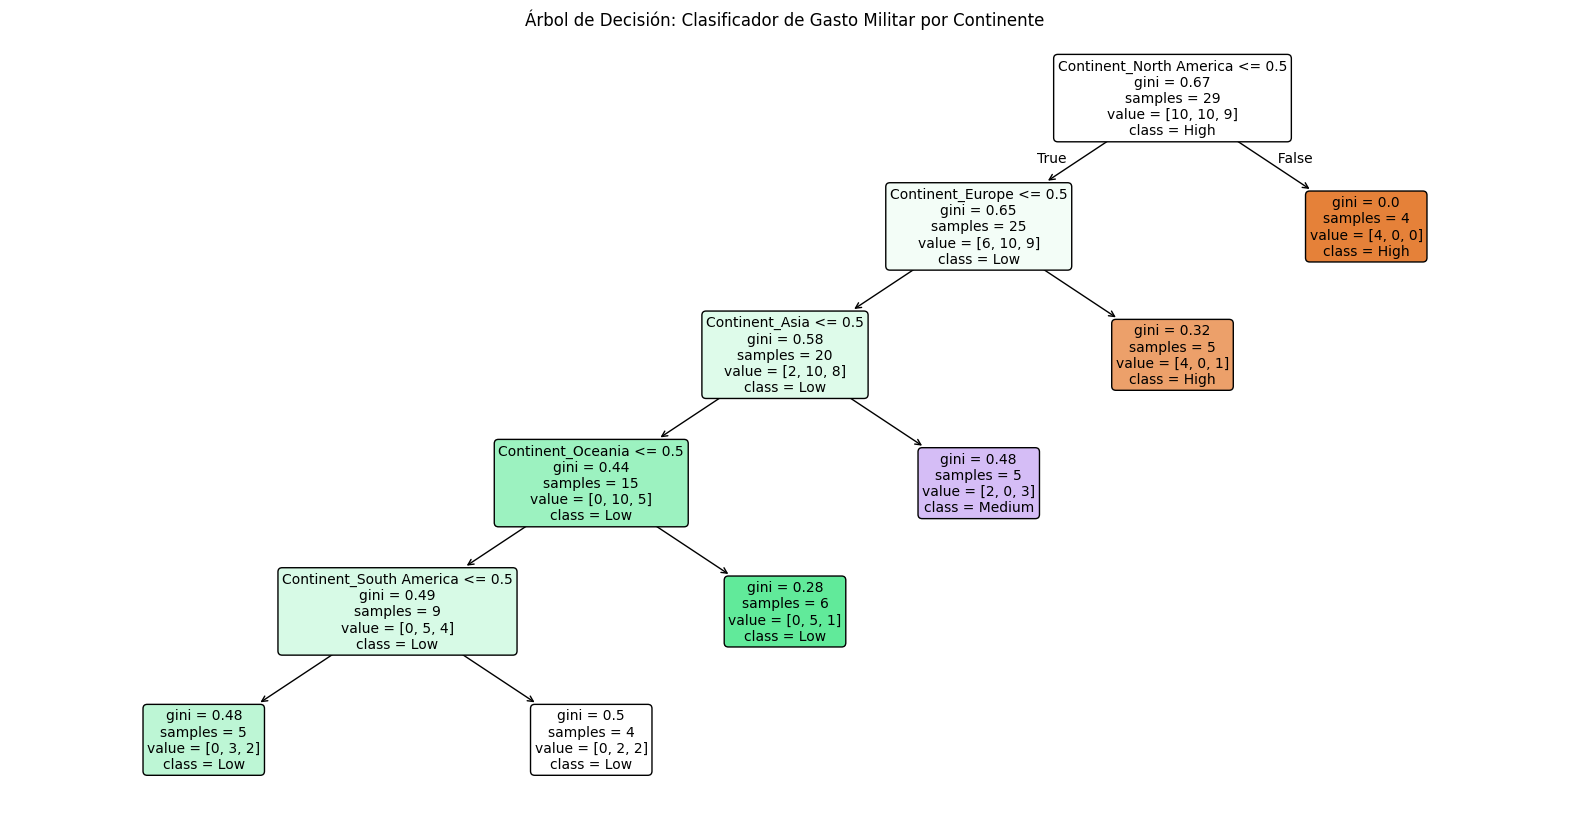

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

# Dibujamos el árbol de clasificación
plot_tree(dtc_model,
          feature_names=X_train_nb.columns.tolist(),
          class_names=dtc_model.classes_,
          filled=True,
          rounded=True,
          precision=2,
          fontsize=10)

plt.title("Árbol de Decisión: Clasificador de Gasto Militar por Continente")
plt.show()

Al observar el árbol de decisiones, se puede inferir cómo los diferentes continentes se agrupan en las categorías de gasto militar (bajo, medio, alto). Por ejemplo, si un nodo del árbol lleva a la clase 'Alto', esto indica que las combinaciones de continentes que llegan a ese nodo tienden a tener un gasto militar elevado, mientras que otras combinaciones llevan a categorías de gasto más bajas.

Para simplificar, el continente norteamerica representa una categoria de gasto militar mas elevado de todos los continentes como se evidencia en el arbol.

### Conclusión del Modelo de Árbol de Decisiones

El Árbol de Decisiones mostró un rendimiento ligeramente mejor que Naive Bayes en este dataset, con una precisión general más alta. La ventaja de este modelo es su interpretabilidad, permitiendo entender qué continentes están asociados con qué categorías de gasto militar. Sin embargo, su rendimiento aún podría mejorar con más datos o características.

## Modelo 3: K-Means para Agrupación de Gasto Militar por País y Año

### Objetivo del Modelo K-Means

El objetivo de aplicar K-Means es identificar grupos (clusters) de registros de gasto militar por país y año que exhiban patrones similares. Como se ve reflejado con nuestro dataset `military-spending-sipri_new.csv`.

### Preparación de Datos para K-Means

Para K-Means, es crucial escalar las características numéricas para que ninguna domine la distancia euclidiana. También necesitamos codificar la columna `Entity` (país) en un formato numérico que el algoritmo pueda procesar. Usaremos `OneHotEncoder` para los países y `StandardScaler` para las variables numéricas `Year` y `Military expenditure`.

In [ ]:
# Cargamos el dataset 'military-spending-sipri_new.csv'
df_kmeans = pd.read_csv("/content/military-spending-sipri_new.csv", low_memory=False)
df_kmeans = df_kmeans.drop(columns=['Unnamed: 0']).copy()

# Codificación One-Hot para 'Entity'
ohe_kmeans = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
entity_encoded_kmeans = ohe_kmeans.fit_transform(df_kmeans[['Entity']])
entity_df_kmeans = pd.DataFrame(
    entity_encoded_kmeans,
    columns=ohe_kmeans.get_feature_names_out(['Entity']),
    index=df_kmeans.index
)

# Escalado de 'Year' y 'Military expenditure'
scaler_kmeans = StandardScaler()
df_kmeans[['Year_scaled', 'Military_expenditure_scaled']] = scaler_kmeans.fit_transform(df_kmeans[['Year', 'Military expenditure']])

# Combinamos todas las características
X_kmeans = pd.concat([
    df_kmeans[['Year_scaled', 'Military_expenditure_scaled']],
    entity_df_kmeans
], axis=1)

display(X_kmeans.head())

,Year_scaled,Military_expenditure_scaled,Entity_Afghanistan,Entity_Africa (SIPRI),Entity_Albania,Entity_Algeria,Entity_Americas (SIPRI),Entity_Angola,Entity_Argentina,Entity_Armenia,Entity_Asia & Oceania (SIPRI),Entity_Australia,Entity_Austria,Entity_Azerbaijan,Entity_Bahrain,Entity_Bangladesh,Entity_Belarus,Entity_Belgium,Entity_Belize,Entity_Benin,Entity_Bolivia,Entity_Bosnia and Herzegovina,Entity_Botswana,Entity_Brazil,Entity_Brunei,Entity_Bulgaria,Entity_Burkina Faso,Entity_Burundi,Entity_Cambodia,Entity_Cameroon,Entity_Canada,Entity_Cape Verde,Entity_Central African Republic,Entity_Central America and the Caribbean (SIPRI),Entity_Central Asia (SIPRI),Entity_Central Europe (SIPRI),Entity_Chad,Entity_Chile,Entity_China,Entity_Colombia,Entity_Congo,Entity_Costa Rica,Entity_Cote d'Ivoire,Entity_Croatia,Entity_Cyprus,Entity_Czechia,Entity_Czechoslovakia,Entity_Democratic Republic of Congo,Entity_Denmark,Entity_Djibouti,Entity_Dominican Republic,Entity_East Asia (SIPRI),Entity_East Germany,Entity_East Timor,Entity_Eastern Europe (SIPRI),Entity_Ecuador,Entity_Egypt,Entity_El Salvador,Entity_Equatorial Guinea,Entity_Estonia,Entity_Eswatini,Entity_Ethiopia,Entity_Europe (SIPRI),Entity_European Union (SIPRI),Entity_Fiji,Entity_Finland,Entity_France,Entity_Gabon,Entity_Gambia,Entity_Georgia,Entity_Germany,Entity_Ghana,Entity_Greece,Entity_Guatemala,Entity_Guinea,Entity_Guinea-Bissau,Entity_Guyana,Entity_Haiti,Entity_Honduras,Entity_Hungary,Entity_Iceland,Entity_India,Entity_Indonesia,Entity_Iran,Entity_Iraq,Entity_Ireland,Entity_Israel,Entity_Italy,Entity_Jamaica,Entity_Japan,Entity_Jordan,Entity_Kazakhstan,Entity_Kenya,Entity_Kosovo,Entity_Kuwait,Entity_Kyrgyzstan,Entity_Laos,Entity_Latvia,Entity_Lebanon,Entity_Lesotho,Entity_Liberia,Entity_Libya,Entity_Lithuania,Entity_Luxembourg,Entity_Madagascar,Entity_Malawi,Entity_Malaysia,Entity_Mali,Entity_Malta,Entity_Mauritania,Entity_Mauritius,Entity_Mexico,Entity_Middle East (SIPRI),Entity_Moldova,Entity_Mongolia,Entity_Montenegro,Entity_Morocco,Entity_Mozambique,Entity_Myanmar,Entity_Namibia,Entity_Nepal,Entity_Netherlands,Entity_New Zealand,Entity_Nicaragua,Entity_Niger,Entity_Nigeria,Entity_North Africa (SIPRI),Entity_North America (SIPRI),Entity_North Macedonia,Entity_Norway,Entity_Oceania (SIPRI),Entity_Oman,Entity_Pakistan,Entity_Panama,Entity_Papua New Guinea,Entity_Paraguay,Entity_Peru,Entity_Philippines,Entity_Poland,Entity_Portugal,Entity_Qatar,Entity_Romania,Entity_Russia,Entity_Rwanda,Entity_Saudi Arabia,Entity_Senegal,Entity_Serbia,Entity_Seychelles,Entity_Sierra Leone,Entity_Singapore,Entity_Slovakia,Entity_Slovenia,Entity_South Africa,Entity_South America (SIPRI),Entity_South Asia (SIPRI),Entity_South East Asia (SIPRI),Entity_South Korea,Entity_South Sudan,Entity_Spain,Entity_Sri Lanka,Entity_Sub-Saharan Africa (SIPRI),Entity_Sudan,Entity_Sweden,Entity_Switzerland,Entity_Taiwan,Entity_Tajikistan,Entity_Tanzania,Entity_Thailand,Entity_Togo,Entity_Trinidad and Tobago,Entity_Tunisia,Entity_Turkey,Entity_Turkmenistan,Entity_USSR,Entity_Uganda,Entity_Ukraine,Entity_United Arab Emirates,Entity_United Kingdom,Entity_United States,Entity_Uruguay,Entity_Uzbekistan,Entity_Venezuela,Entity_Vietnam,Entity_Western Europe (SIPRI),Entity_World,Entity_Yemen,Entity_Yemen Arab Republic,Entity_Zambia,Entity_Zimbabwe
0,-1.357389,-0.203362,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

### Determinación del Número Óptimo de Clusters

Para K-Means, elegir el número adecuado de clusters (K) es fundamental. Utilizamos el método del codo y silueta.

Calculando metricas...
El codo esta en k = 3


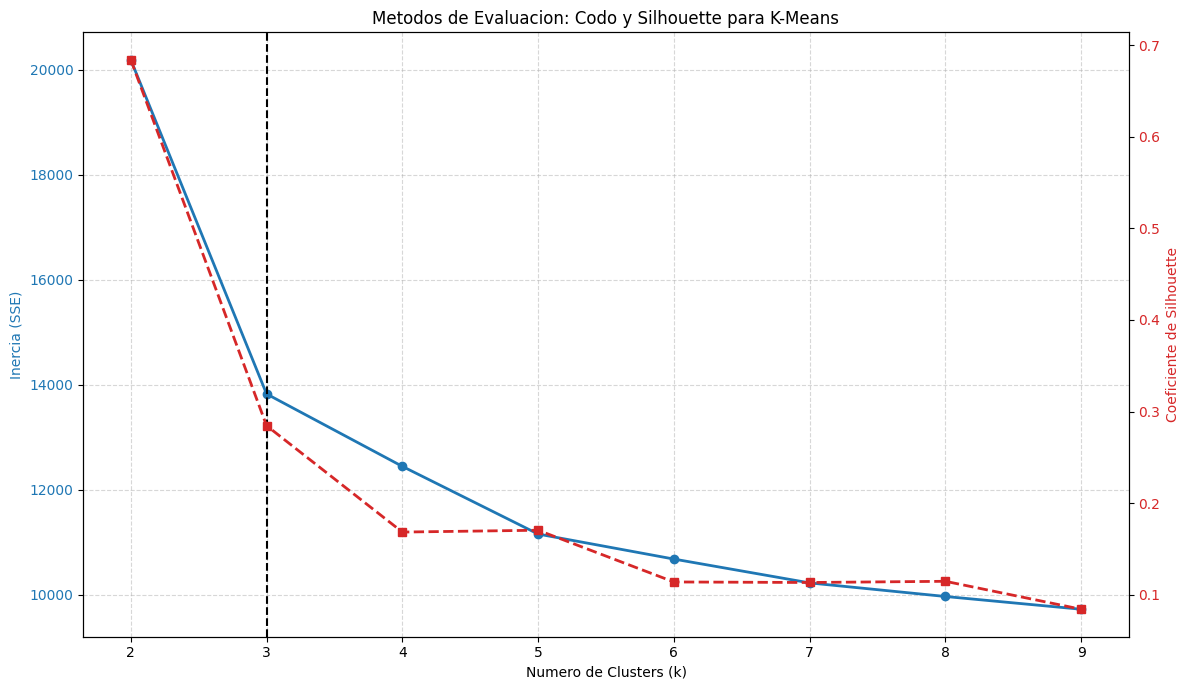

In [ ]:
!pip install kneed

from kneed import KneeLocator

sse = []
silhouette_scores = []
rango_k = range(2, 10) # Probamos con 2 a 9 clusters, 1 cluster no permite calcular silhouette score

print("Calculando metricas...")

for k in rango_k:
    kmeans_eval = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans_eval.fit(X_kmeans)
    labels = kmeans_eval.labels_
    sse.append(kmeans_eval.inertia_)
    silhouette_scores.append(silhouette_score(X_kmeans, labels))

# Detectamos el codo de forma automatica
kl = KneeLocator(rango_k, sse, curve="convex", direction="decreasing")
print(f"El codo esta en k = {kl.elbow}")

# Graficamos ambos metodos para tomar la decision
fig, ax1 = plt.subplots(figsize=(12, 7))

# Eje izquierdo para el Codo (Inercia)
color = 'tab:blue'
ax1.set_xlabel('Numero de Clusters (k)')
ax1.set_ylabel('Inercia (SSE)', color=color)
ax1.plot(rango_k, sse, marker='o', color=color, linewidth=2, label='Inercia')
if kl.elbow:
    ax1.axvline(x=kl.elbow, color='black', linestyle='--', label=f'Codo detectado (k={kl.elbow})')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Eje derecho para la Silueta
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Coeficiente de Silhouette', color=color)
ax2.plot(rango_k, silhouette_scores, marker='s', color=color, linewidth=2, linestyle='--', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Metodos de Evaluacion: Codo y Silhouette para K-Means')
fig.tight_layout()
plt.show()

En este gráfico interpretamos los datos del DataFrame X_kmeans, el cual está compuesto por el 'Año' escalado, el 'Gasto Militar' también escalado, y una representación codificada One-Hot de cada 'Entidad' como país o continente. Básicamente, está analizando cómo se agrupan los diferentes registros de gasto militar por entidad y año en función de estos valores.

### Aplicación del Algoritmo K-Means con k Óptimo
Basándonos en la visualización combinada del método del codo (SSE) y el coeficiente de Silhouette, hemos determinado el número óptimo de clusters (`k_optimo`). Este valor es crucial para aplicar el algoritmo K-Means de manera efectiva, permitiéndonos agrupar los datos de gasto militar por país y año en segmentos coherentes que exhiben patrones similares.

In [ ]:
if kl.elbow:
    k_optimo = kl.elbow
else:
    k_optimo = 3

print(f"Aplicando K-Means con el número óptimo de clusters: k = {k_optimo}")

kmeans_model_optimal = KMeans(n_clusters=k_optimo, init='k-means++', max_iter=300, n_init=10, random_state=42)
df_kmeans['Cluster'] = kmeans_model_optimal.fit_predict(X_kmeans)

print("\n--- Cantidad de elementos asignados por cluster ---")
print(df_kmeans['Cluster'].value_counts().sort_index())

print("\n--- Características promedio de cada cluster ---")
cluster_summary = df_kmeans.groupby('Cluster')[['Year', 'Military expenditure']].mean()
display(cluster_summary)

entity_features = [col for col in X_kmeans.columns if 'Entity_' in col]

cluster_centers_entities = pd.DataFrame(kmeans_model_optimal.cluster_centers_[:, len(['Year_scaled', 'Military_expenditure_scaled']):], columns=entity_features)

print("\n--- Top 5 entidades (países) con mayor representación en el centroide de cada cluster ---")
for i in range(k_optimo):
    print(f"\nCLUSTER {i}:")
    top_entities_in_cluster = cluster_centers_entities.loc[i].nlargest(5)
    print(top_entities_in_cluster.index.str.replace('Entity_', '').tolist())

display(df_kmeans.head())

Aplicando K-Means con el número óptimo de clusters: k = 3

--- Cantidad de elementos asignados por cluster ---
Cluster
0    3550
1    5291
2     188
Name: count, dtype: int64

--- Características promedio de cada cluster ---


,Year,Military expenditure
Cluster,,
0,1975.959437,7.358366e+09
1,2008.695899,1.503098e+10
2,2001.712766,9.468415e+11



--- Top 5 entidades (países) con mayor representación en el centroide de cada cluster ---

CLUSTER 0:
['Italy', 'Luxembourg', 'Mexico', 'Netherlands', 'Norway']

CLUSTER 1:
['East Asia (SIPRI)', 'Western Europe (SIPRI)', 'Africa (SIPRI)', 'Angola', 'Central America and the Caribbean (SIPRI)']

CLUSTER 2:
['United States', 'Americas (SIPRI)', 'North America (SIPRI)', 'World', 'Asia & Oceania (SIPRI)']


,Entity,Year,Military expenditure,Year_scaled,Military_expenditure_scaled,Cluster
0,Afghanistan,1970,68814760.0,-1.357389,-0.203362,0
1,Afghanistan,1973,79796820.0,-1.198811,-0.203290,0
2,Afghanistan,1974,77561210.0,-1.145952,-0.203305,0
3,Afghanistan,1975,81419624.0,-1.093092,-0.203280,0
4,Afghanistan,1976,103842290.0,-1.040233,-0.203134,0


Aqui tomamos el número óptimo de clusters determinados en el paso anterior y los utilizamos para aplicar el grafico K-Means. Luego, analiza y muestra las características clave de cada cluster formado.

### Análisis y Visualización de los Clusters

Una vez que los clusters han sido formados, analizamos las características de cada uno para entender qué patrones representan. Esto puede incluir el gasto militar promedio, los años predominantes o los países más comunes dentro de cada cluster.

,Year,Military expenditure
Cluster,,
0,1975.959437,7.358366e+09
1,2008.695899,1.503098e+10
2,2001.712766,9.468415e+11


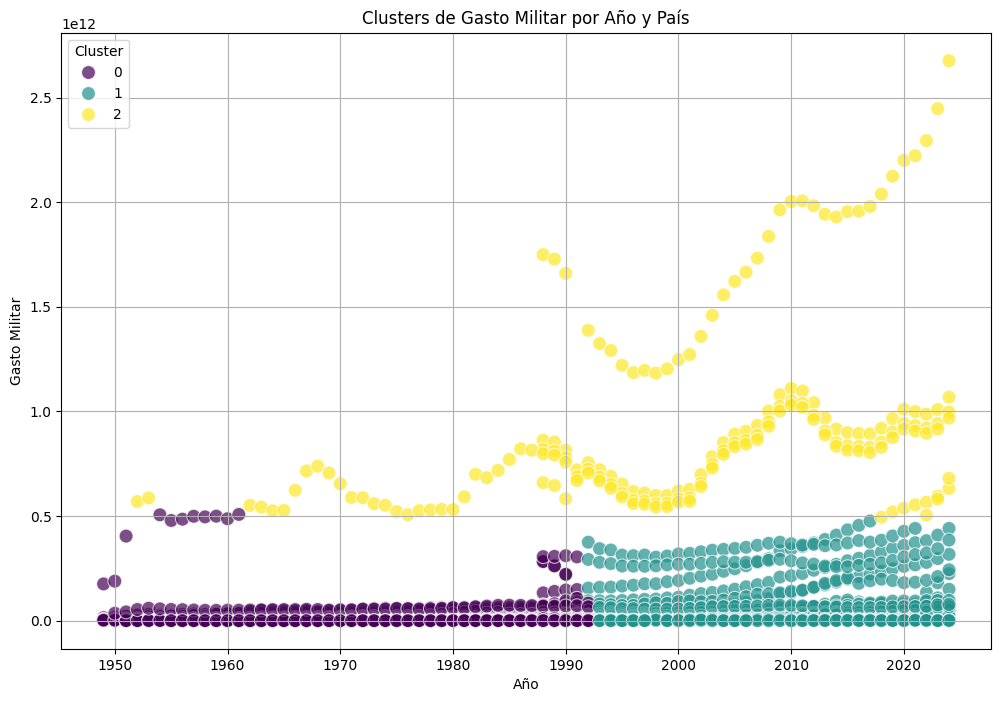

In [ ]:
# Análisis de los centroides de los clusters (en el espacio original o escalado)
cluster_means = df_kmeans.groupby('Cluster')[['Year', 'Military expenditure']].mean()
display(cluster_means)

# Visualización de los clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Year', y='Military expenditure', hue='Cluster', data=df_kmeans, palette='viridis', s=100, alpha=0.7)
plt.title('Clusters de Gasto Militar por Año y País')
plt.xlabel('Año')
plt.ylabel('Gasto Militar')
plt.grid(True)
plt.show()

### Conclusión del Modelo K-Means

K-Means ha identificado distintos grupos en los datos de gasto militar. Los clusters revelan patrones donde ciertos países o períodos de tiempo tienen niveles de gasto militar similares.